In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from keras.models import Sequential
from keras.layers import Dense, Dropout, LSTM
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

In [2]:
dataset_train = pd.read_csv('Salestrain.csv')
dataset_train.shape

(96, 1)

In [3]:
dataset_test = pd.read_csv('Salestest.csv')
dataset_test.shape

(48, 1)

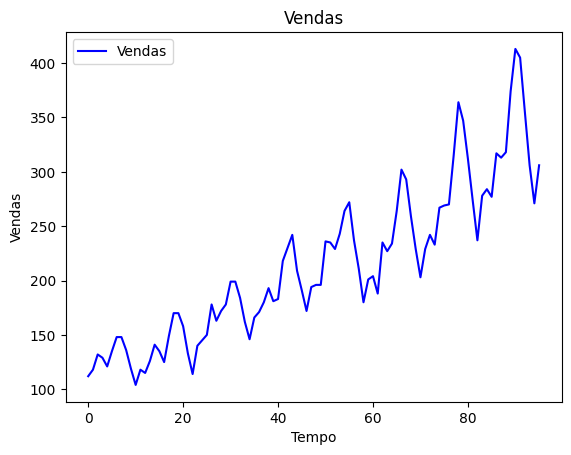

In [4]:
plt.plot(dataset_train, color='blue', label='Vendas')
plt.title('Vendas')
plt.xlabel('Tempo')
plt.ylabel('Vendas')
plt.legend()
plt.show()

In [5]:
sc = MinMaxScaler(feature_range=(0, 1))
training_set_scaled = sc.fit_transform(dataset_train)

In [6]:
X_train = []
y_train = []
for i in range(90, len(training_set_scaled)):
  data = training_set_scaled[i-90:i, 0]
  X_train.append(data)
  y_train.append(training_set_scaled[i, 0])

X_train = np.array(X_train).reshape(-1, 90, 1)
y_train = np.array(y_train)

In [7]:
model = Sequential()
model.add(LSTM(units=100, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(LSTM(units=100, return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(units=100, return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(units=100))
model.add(Dropout(0.2))
model.add(Dense(units=1))
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(X_train, y_train, epochs=300, batch_size=1)

Epoch 1/300


/Users/caio.motta/.pyenv/versions/3.11.11/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - loss: 0.4955
Epoch 2/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - loss: 0.0373
Epoch 3/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - loss: 0.1064
Epoch 4/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - loss: 0.0518
Epoch 5/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - loss: 0.1141
Epoch 6/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - loss: 0.0435
Epoch 7/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - loss: 0.0664
Epoch 8/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - loss: 0.0385
Epoch 9/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - loss: 0.0340
Epoch 10/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - loss: 0.0546
Epoch 11/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - loss: 0.0353
Epoch 12/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - loss: 0.0273
Epoch 13/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - loss: 0.0561
Epoch 14/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - loss: 0.0331
Epoch 15/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - loss: 0.0434
Epoch 16/300
6/6 ━━━━━━━━━━━━━━